In [ ]:
# !pip install skrebate

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gc
import os
import sys

import warnings
warnings.filterwarnings('ignore')

In [2]:
from pathlib import Path

In [6]:
IMP_GENES = [
'ABCC5',
'ABCF3',
'ACAP2',
'ACTL6A',
'AP2M1',
'ATP11B',
'CLDN1',
'COL7A1',
'DCUN1D1',
'DLG1',
'DVL3',
'FBXO45',
'FXR1',
'FYTTD1',
'GMPS',
'KPNA4',
'LRRC31',
'LSG1',
'MED12L',
'MFN1',
'MYNN',
'OPA1',
'P2RY1',
'PAK2',
'PARL',
'PCYT1A',
'PDCD10',
'PIGX',
'PIK3CA',
'PLCH1',
'PLD1',
'PSMD2',
'RFC4',
'RNF168',
'RSRC1',
'SEMA3F',
'SENP5',
'SIAH2',
'SOX2',
'TBCCD1',
'TFRC',
'TP63',
'TRA2B',
'UCN2',
'WDR53',
'YEATS2',
'ZNF639'
]

In [4]:

seed = 10

rna_luad_xena = pd.read_csv(os.path.join('Z:\multiomics based manuscript\datasets\gene_exp\with_common_patients_processed', 'csv_rna_common_luad.csv'))
rna_lusc_xena = pd.read_csv(os.path.join('Z:\multiomics based manuscript\datasets\gene_exp\with_common_patients_processed', 'csv_rna_common_lusc.csv'))
df_rna_xena = pd.concat([rna_luad_xena, rna_lusc_xena], axis=0)

cnv_luad_xena = pd.read_csv(os.path.join('Z:\multiomics based manuscript\datasets\cnv\with_common_patients_processed', 'csv_cnv_common_luad.csv'))
cnv_lusc_xena = pd.read_csv(os.path.join('Z:\multiomics based manuscript\datasets\cnv\with_common_patients_processed', 'csv_cnv_common_lusc.csv'))
df_cnv_xena = pd.concat([cnv_luad_xena, cnv_lusc_xena], axis=0)


_df_rna_xena = df_rna_xena.sample(frac=1, replace=False, ignore_index=True, random_state = seed)
_df_cnv_xena = df_cnv_xena.sample(frac=1, replace=False, ignore_index=True, random_state = seed)


In [9]:
_df_cnv_xena = df_cnv_xena[df_cnv_xena.columns.intersection(IMP_GENES)]
_df_rna_xena = df_rna_xena[df_rna_xena.columns.intersection(IMP_GENES)]

In [10]:
_df_cnv_xena

,UCN2,COL7A1,SEMA3F,SIAH2,MED12L,P2RY1,PLCH1,GMPS,RSRC1,KPNA4,...,TFRC,PCYT1A,RNF168,WDR53,FBXO45,PIGX,DLG1,PAK2,SENP5,FYTTD1
0,-0.198,-0.198,-0.198,-0.206,-1.293,-0.201,-0.201,-0.201,-0.201,-0.201,...,-0.201,-0.201,-0.201,-0.201,-0.201,-0.201,-0.201,-0.201,-0.201,-0.201
1,-0.410,-0.410,-0.410,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.015,0.015,0.015,0.015,0.015,0.015,0.015,0.015,0.015,0.015
2,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,...,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000
3,0.053,0.053,0.053,0.053,0.053,0.053,0.053,0.053,0.053,0.043,...,0.043,0.043,0.043,0.043,0.043,0.043,0.043,0.043,0.043,0.043
4,0.379,0.379,0.379,0.754,0.754,0.754,0.754,0.754,0.754,0.754,...,0.754,0.754,0.754,0.754,0.754,0.754,0.754,0.754,0.754,0.754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478,-0.166,-0.166,-0.166,0.883,0.883,0.883,0.883,0.883,0.883,0.883,...,0.883,0.883,0.883,0.883,0.883,0.883,0.883,0.883,0.883,0.883
479,-0.499,-0.499,-0.499,2.730,2.730,2.730,2.730,2.730,3.217,3.217,...,3.110,3.110,3.110,3.110,3.110,3.110,3.110,3.110,3.110,3.110
480,-0.236,-0.236,-0.236,0.715,0.715,0.715,0.715,0.715,0.715,0.715,...,0.656,0.656,0.656,0.656,0.656,0.656,0.656,0.656,0.656,0.656
481,-0.311,-0.311,-0.311,-0.138,-0.138,-0.138,-0.138,-0.138,0.702,0.702,...,0.727,0.727,0.727,0.727,0.727,0.727,0.727,0.727,0.727,0.727


In [11]:
_df_rna_xena

,OPA1,COL7A1,PIGX,PCYT1A,CLDN1,KPNA4,AP2M1,TP63,PIK3CA,SENP5,...,UCN2,WDR53,ATP11B,MYNN,ZNF639,PSMD2,YEATS2,SOX2,ABCC5,ACAP2
0,9.4001,7.8752,8.2278,7.7543,10.2323,9.7711,12.2283,5.1322,7.4384,9.2787,...,2.6420,6.8423,9.2492,7.8492,8.5046,11.1844,9.3966,7.8976,9.7909,8.6827
1,10.4485,12.8499,8.8845,8.3204,10.7543,10.3876,12.3839,9.3054,8.2397,9.5034,...,7.5124,7.5165,10.1794,8.3433,9.4165,12.7925,10.1665,5.2414,10.0405,9.1608
2,10.1311,6.6390,8.8741,8.6035,10.5512,10.2782,12.4932,8.1869,8.4371,9.1858,...,2.1192,7.0135,10.3661,8.3827,8.9925,12.0745,9.6392,10.0621,9.7083,9.7851
3,10.5159,8.5374,8.6811,9.0735,8.0090,10.7099,13.1130,6.9294,8.2607,9.9389,...,3.7555,7.1525,10.6412,8.3267,9.1389,12.6896,10.5612,6.3339,10.1034,10.1228
4,11.4658,6.7004,9.8733,8.7301,11.4955,11.3484,13.2057,7.0244,9.2464,10.0516,...,1.1136,7.8103,10.9682,8.7517,10.1649,12.5778,10.4749,7.3519,9.3401,10.7511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478,11.5136,13.6875,10.2272,10.6022,14.1630,11.3417,13.8801,13.8931,9.9515,10.4271,...,6.6998,8.3369,11.6737,9.6853,10.0594,13.2374,11.7293,11.3112,12.5023,11.1047
479,11.8225,10.1875,10.8850,11.3754,14.9810,12.3054,14.4380,13.9693,9.9445,11.1379,...,3.4818,9.3401,12.3726,10.5711,10.8249,13.9831,11.0572,11.4610,14.1503,12.7141
480,11.7493,13.1856,10.7061,9.7947,12.1874,11.6008,13.6029,14.1314,10.7540,10.8012,...,8.1273,8.5527,12.1701,9.3915,10.9198,13.4158,11.3527,13.4480,13.5501,11.8088
481,11.2688,11.5359,8.6795,9.4625,14.1737,11.5578,13.2681,12.2836,9.5119,10.4207,...,6.4965,8.3353,10.6215,10.4657,9.9667,13.1448,10.5471,7.7543,10.1005,11.0727


In [44]:
'''
Compute pearson and spearman correlation
'''

import seaborn as sns
plt.rcParams['font.family'] = 'Times New Roman'

# Compute Pearson correlation
pearson_corr_rna = _df_rna_xena.corr(method='spearman')
pearson_corr_cnv = _df_cnv_xena.corr(method='spearman')


In [47]:
ROOT = Path('Z:/multiomics based manuscript/REVISION AFTER JMS/OUP_BA_REVIEWER_COMMENTS/training_cohort/RESULTS/IMP_GENES_RELIEFF/USING_KFOLD')

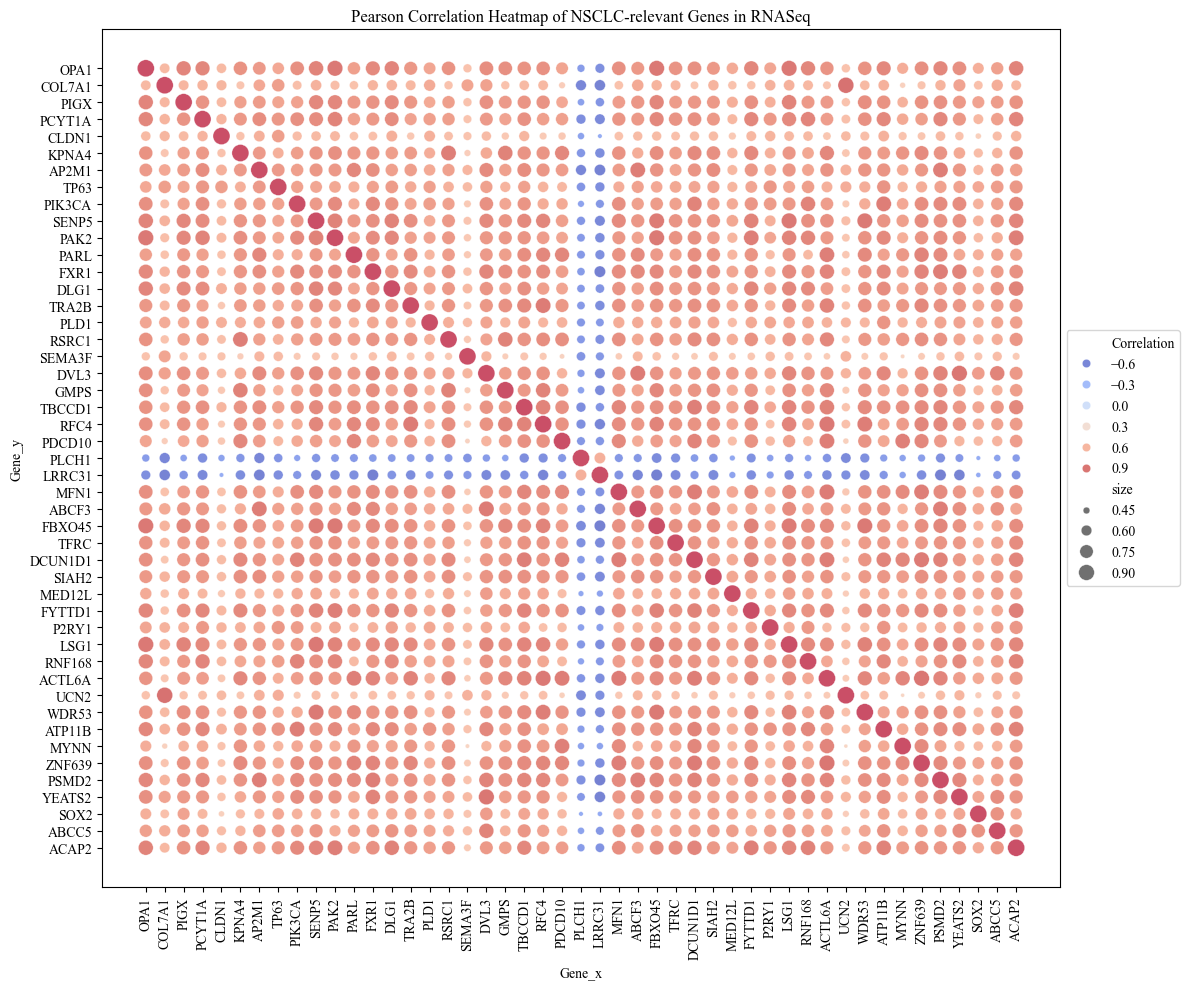

In [48]:
corr_melted = pearson_corr_rna.reset_index().melt(id_vars='index')
corr_melted.columns = ['Gene_x', 'Gene_y', 'Correlation']

# Normalize correlation magnitude for bubble size
corr_melted['size'] = corr_melted['Correlation'].abs()

# -------------- Bubble Heatmap -----------------------
plt.figure(figsize=(12, 10))
bubble_plot = sns.scatterplot(
    data=corr_melted,
    x="Gene_x",
    y="Gene_y",
    hue="Correlation",
    size="size",
    sizes=(8, 150),
    palette="coolwarm",
    linewidth=0.3,
    alpha=0.7
)

plt.xticks(rotation=90)
plt.title("Pearson Correlation Heatmap of NSCLC-relevant Genes in RNASeq")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig(ROOT / "bubble_heatmap_rna.png", dpi=400, bbox_inches="tight")

plt.tight_layout()
plt.show()

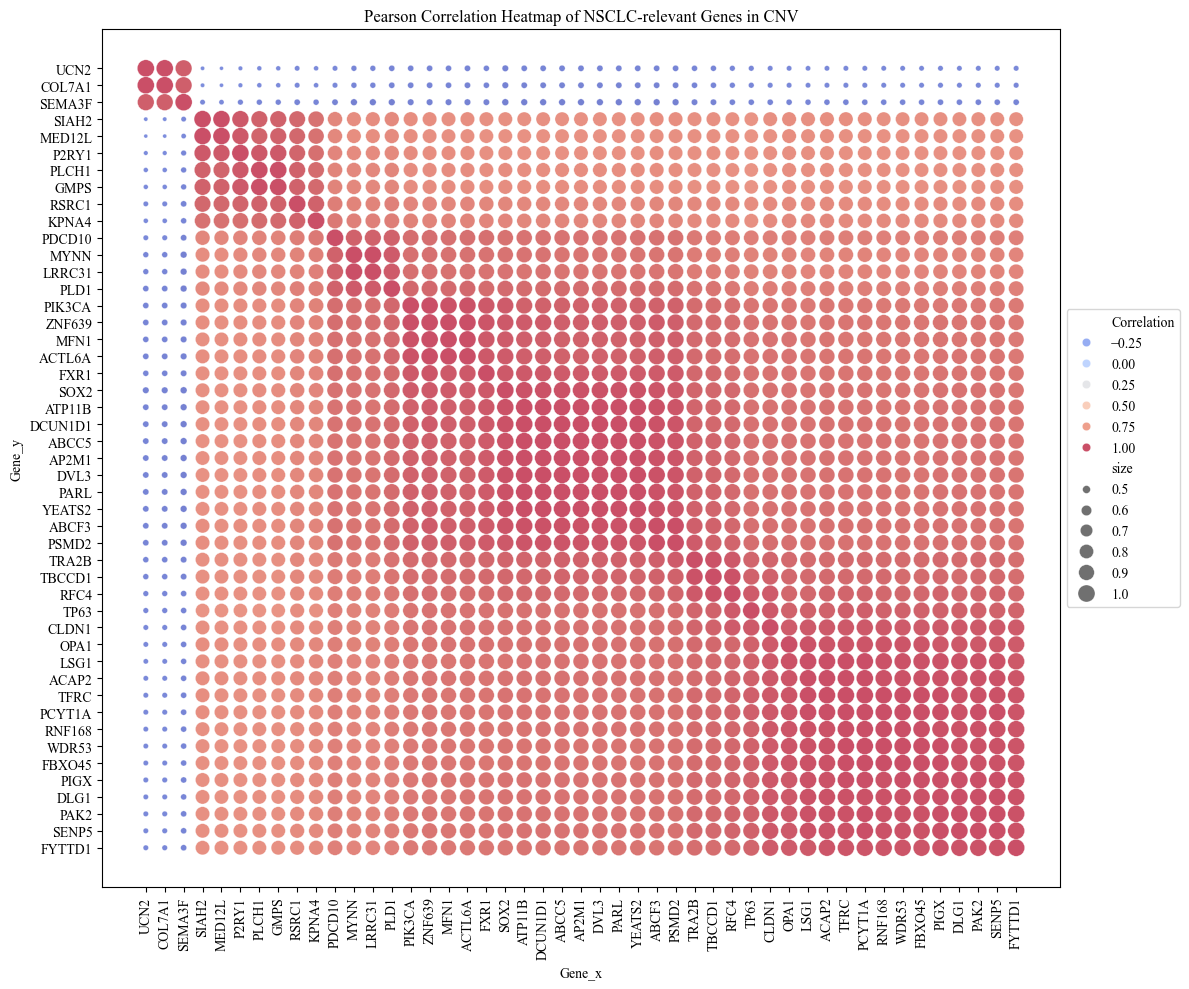

In [49]:
corr_melted = pearson_corr_cnv.reset_index().melt(id_vars='index')
corr_melted.columns = ['Gene_x', 'Gene_y', 'Correlation']

# Normalize correlation magnitude for bubble size
corr_melted['size'] = corr_melted['Correlation'].abs()

# -------------- Bubble Heatmap -----------------------
plt.figure(figsize=(12, 10))
bubble_plot = sns.scatterplot(
    data=corr_melted,
    x="Gene_x",
    y="Gene_y",
    hue="Correlation",
    size="size",
    sizes=(8, 150),
    palette="coolwarm",
    linewidth=0.3,
    alpha=0.7
)

plt.xticks(rotation=90)
plt.title("Pearson Correlation Heatmap of NSCLC-relevant Genes in CNV")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.savefig(ROOT / "bubble_heatmap_cnv.png", dpi=400, bbox_inches="tight")
plt.tight_layout()
plt.show()

---